# Cross-Model Feature Importance for Type 2 Diabetes Prediction
## ANN Model — Grid Search + Final Training + Evaluation

**INFO 5368 · Cornell Tech**

Pipeline:
1. Load preprocessed data + validation split
2. **§4** Proposal grid search (`lr × hidden × epochs`, 1-layer)
3. **§5** Plot grid results
4. **§5.5** Refined 1-layer search (adds `weight_decay × batch_size`)
5. **§5.6** 2-layer search (using `ANN2` from `ann_model.py`)
6. **§5.7** Cross-architecture leaderboard
7. **§5.8** Decision-threshold tuning on the global winner
8. **§6** Final training + evaluation + permutation importance

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time, csv

from preprocess import load_preprocessed, preprocess_pipeline
from ann_model import (
    ANN, ANN2, ANNNet, ANNNet2, ANNConfig,
    AdamOptimizer, stable_sigmoid, bce_with_logits,
    grid_search,
)
from knn_model import compute_metrics, print_metrics, permutation_importance

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 100

print('Imports loaded.')

Imports loaded.


## 1. Load Preprocessed Data

Tries `models/*.npy` first; falls back to running the full preprocessing
pipeline if those files aren't present (e.g. on a fresh Colab session).

In [2]:
try:
    X_train, X_test, y_train, y_test, feature_names, scaler = load_preprocessed()
    print('Loaded preprocessed data from models/')
except FileNotFoundError:
    print('Preprocessed files not found — running preprocess pipeline...')
    X_train, X_test, y_train, y_test, feature_names, scaler = preprocess_pipeline(
        save=True, run_eda_flag=False
    )

print(f'\nX_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Class balance — train 0:{(y_train==0).sum()}  1:{(y_train==1).sum()}')
print(f'                test  0:{(y_test==0).sum()}   1:{(y_test==1).sum()}')
print(f'Features ({len(feature_names)}): {feature_names}')

Loaded preprocessed data from models/

X_train: (54810, 21)   X_test: (13701, 21)
Class balance — train 0:27888  1:26922
                test  0:6971   1:6730
Features (21): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth']


## 2. Validation Split

Hold out 20% of the training set as a validation fold for grid search /
early stopping. Same convention as `knn_notebook.ipynb` and `ann_model.py`.

In [3]:
rng     = np.random.default_rng(SEED)
val_idx = rng.choice(len(X_train), size=int(0.2 * len(X_train)), replace=False)
tr_idx  = np.setdiff1d(np.arange(len(X_train)), val_idx)
X_tr, X_val = X_train[tr_idx], X_train[val_idx]
y_tr, y_val = y_train[tr_idx], y_train[val_idx]

print(f'Train: {X_tr.shape}   Val: {X_val.shape}')
print(f'Train class balance  0:{(y_tr==0).sum()}  1:{(y_tr==1).sum()}')
print(f'Val   class balance  0:{(y_val==0).sum()}  1:{(y_val==1).sum()}')

Train: (43848, 21)   Val: (10962, 21)
Train class balance  0:22332  1:21516
Val   class balance  0:5556  1:5406


## 3. ANN Architecture

**1-layer** (`ANNNet`, proposal §IV.A.2 Eq. 5):
$$h = \mathrm{ReLU}(W_1 x + b_1) \quad\quad \hat{y} = \sigma(W_2 h + b_2)$$

**2-layer** (`ANNNet2`, extension):
$$h_1 = \mathrm{ReLU}(W_1 x + b_1) \quad h_2 = \mathrm{ReLU}(W_2 h_1 + b_2) \quad \hat{y} = \sigma(W_3 h_2 + b_3)$$

Both use BCE-with-logits loss, Adam optimizer (NumPy), L2 weight decay, and
early stopping. Implementation lives in `ann_model.py`.

In [4]:
demo1 = ANNNet (input_dim=X_tr.shape[1], hidden_dim=64)
demo2 = ANNNet2(input_dim=X_tr.shape[1], hidden_dims=(128, 64))

for label, net in [('1-layer h=64', demo1), ('2-layer (128,64)', demo2)]:
    n_params = sum(v.size for v in net.params.values())
    shapes = ', '.join(f'{k}={v.shape}' for k, v in net.params.items())
    print(f'{label:20s}  total params = {n_params:>6,}    {shapes}')

1-layer h=64          total params =  1,473    W1=(21, 64), b1=(64,), W2=(64, 1), b2=(1,)
2-layer (128,64)      total params = 11,137    W1=(21, 128), b1=(128,), W2=(128, 64), b2=(64,), W3=(64, 1), b3=(1,)


## 4. Hyperparameter Grid Search (proposal §V.B)

- `lr        ∈ {0.001, 0.01}`
- `hidden    ∈ {32, 64, 128}`
- `epochs    ∈ {50, 100, 200}`

→ 2 × 3 × 3 = **18 configs**. Selection criterion: validation F1.
Uses `early_stopping=False` so each config is evaluated at exactly the
specified number of epochs.

In [5]:
LR_VALUES     = (0.001, 0.01)
HIDDEN_VALUES = (32, 64, 128)
EPOCH_VALUES  = (50, 100, 200)

n_configs = len(LR_VALUES) * len(HIDDEN_VALUES) * len(EPOCH_VALUES)
print(f'Grid: {len(LR_VALUES)} × {len(HIDDEN_VALUES)} × {len(EPOCH_VALUES)} '
      f'= {n_configs} configurations\n')

t0 = time.time()
best_cfg, gs_results = grid_search(
    X_tr, y_tr, X_val, y_val,
    lr_values=LR_VALUES,
    hidden_values=HIDDEN_VALUES,
    epoch_values=EPOCH_VALUES,
)
print(f'\nGrid search took {time.time()-t0:.1f}s')
print(f'★ Best config (by val F1): lr={best_cfg.lr}, '
      f'hidden={best_cfg.hidden_dim}, epochs={best_cfg.epochs}')

Grid: 2 × 3 × 3 = 18 configurations

  Testing lr=0.001, hidden=32, epochs=50 ... F1=0.7506  Acc=0.7475  (1.2s)
  Testing lr=0.001, hidden=32, epochs=100 ... F1=0.7426  Acc=0.7462  (2.4s)
  Testing lr=0.001, hidden=32, epochs=200 ... F1=0.7494  Acc=0.7460  (4.9s)
  Testing lr=0.001, hidden=64, epochs=50 ... F1=0.7457  Acc=0.7456  (1.5s)
  Testing lr=0.001, hidden=64, epochs=100 ... F1=0.7391  Acc=0.7455  (3.0s)
  Testing lr=0.001, hidden=64, epochs=200 ... F1=0.7408  Acc=0.7453  (6.3s)
  Testing lr=0.001, hidden=128, epochs=50 ... F1=0.7428  Acc=0.7435  (2.2s)
  Testing lr=0.001, hidden=128, epochs=100 ... F1=0.7393  Acc=0.7452  (4.5s)
  Testing lr=0.001, hidden=128, epochs=200 ... F1=0.7378  Acc=0.7424  (9.0s)
  Testing lr=0.01, hidden=32, epochs=50 ... F1=0.7534  Acc=0.7469  (1.4s)
  Testing lr=0.01, hidden=32, epochs=100 ... F1=0.7519  Acc=0.7466  (3.0s)
  Testing lr=0.01, hidden=32, epochs=200 ... F1=0.7452  Acc=0.7447  (5.3s)
  Testing lr=0.01, hidden=64, epochs=50 ... F1=0.7520  

In [6]:
gs_df = pd.DataFrame(gs_results).round(4)
gs_df.sort_values('f1', ascending=False).reset_index(drop=True)

,lr,hidden_dim,epochs,accuracy,precision,recall,f1,TP,TN,FP,FN,time_s
0,0.010,128,100,0.7479,0.7273,0.7819,0.7536,4227,3971,1585,1179,4.4665
1,0.010,32,50,0.7469,0.7252,0.7839,0.7534,4238,3950,1606,1168,1.3910
2,0.010,64,100,0.7476,0.7283,0.7786,0.7526,4209,3986,1570,1197,3.2301
3,0.010,64,50,0.7484,0.7317,0.7734,0.7520,4181,4023,1533,1225,1.5604
4,0.010,32,100,0.7466,0.7269,0.7788,0.7519,4210,3974,1582,1196,2.9716
5,0.001,32,50,0.7475,0.7316,0.7706,0.7506,4166,4028,1528,1240,1.1833
6,0.001,32,200,0.7460,0.7299,0.7699,0.7494,4162,4016,1540,1244,4.8586
7,0.010,64,200,0.7464,0.7313,0.7679,0.7491,4151,4031,1525,1255,6.4241
8,0.010,128,200,0.7453,0.7312,0.7647,0.7476,4134,4036,1520,1272,8.9871
9,0.010,128,50,0.7459,0.7339,0.7606,0.7470,4112,4065,1491,1294,2.2246


## 5. Visualize Grid Search Results

### 5.1 Validation F1 heatmap (lr × hidden_dim) per epoch

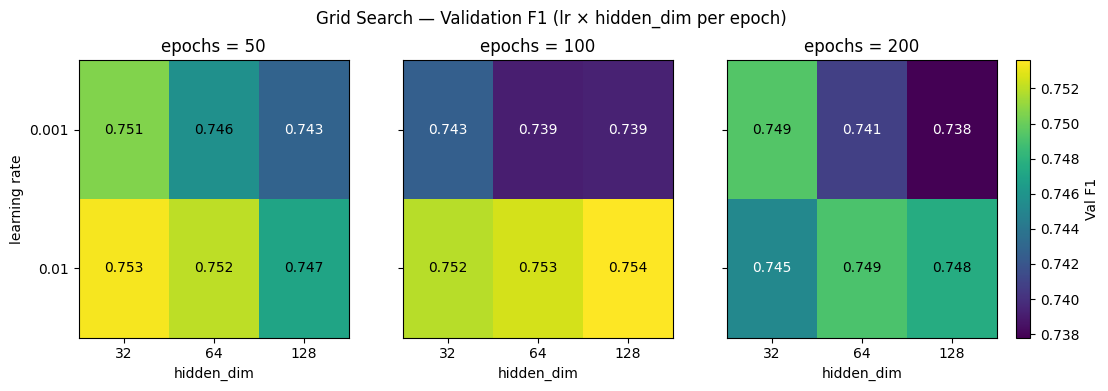

In [7]:
metric_to_plot = 'f1'
epochs_sorted  = sorted(gs_df['epochs'].unique())

fig, axes = plt.subplots(
    1, len(epochs_sorted),
    figsize=(4.2 * len(epochs_sorted), 3.6),
    sharey=True,
)
if len(epochs_sorted) == 1:
    axes = [axes]

vmin = gs_df[metric_to_plot].min()
vmax = gs_df[metric_to_plot].max()

for ax, ep in zip(axes, epochs_sorted):
    sub   = gs_df[gs_df['epochs'] == ep]
    pivot = sub.pivot(index='lr', columns='hidden_dim', values=metric_to_plot)
    im = ax.imshow(pivot.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('hidden_dim')
    if ax is axes[0]:
        ax.set_ylabel('learning rate')
    ax.set_title(f'epochs = {ep}')
    mid = (vmin + vmax) / 2
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v < mid else 'black', fontsize=10)

fig.colorbar(im, ax=axes, label=f'Val {metric_to_plot.upper()}',
             fraction=0.04, pad=0.02)
plt.suptitle('Grid Search — Validation F1 (lr × hidden_dim per epoch)',
             y=1.02, fontsize=12)
plt.show()

### 5.2 Validation Accuracy heatmap (same layout)

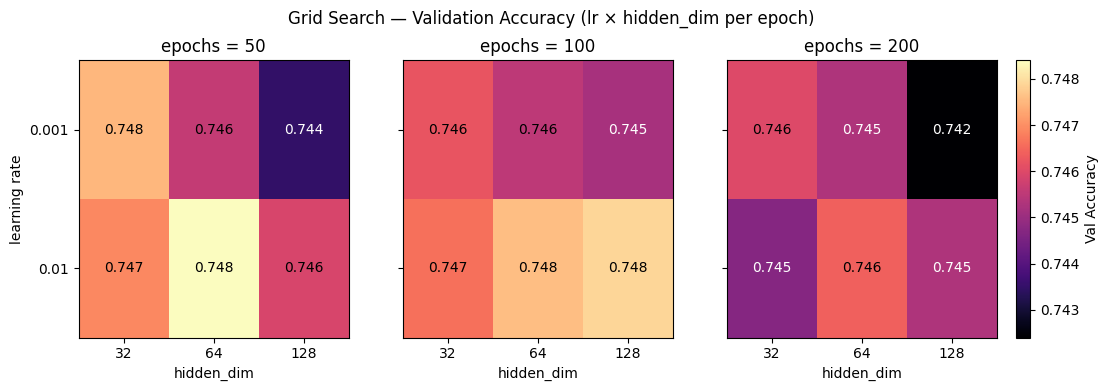

In [8]:
metric_to_plot = 'accuracy'
fig, axes = plt.subplots(
    1, len(epochs_sorted),
    figsize=(4.2 * len(epochs_sorted), 3.6),
    sharey=True,
)
if len(epochs_sorted) == 1:
    axes = [axes]

vmin = gs_df[metric_to_plot].min()
vmax = gs_df[metric_to_plot].max()

for ax, ep in zip(axes, epochs_sorted):
    sub   = gs_df[gs_df['epochs'] == ep]
    pivot = sub.pivot(index='lr', columns='hidden_dim', values=metric_to_plot)
    im = ax.imshow(pivot.values, cmap='magma', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('hidden_dim')
    if ax is axes[0]:
        ax.set_ylabel('learning rate')
    ax.set_title(f'epochs = {ep}')
    mid = (vmin + vmax) / 2
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v < mid else 'black', fontsize=10)

fig.colorbar(im, ax=axes, label='Val Accuracy', fraction=0.04, pad=0.02)
plt.suptitle('Grid Search — Validation Accuracy (lr × hidden_dim per epoch)',
             y=1.02, fontsize=12)
plt.show()

### 5.3 Validation F1 vs hidden_dim, grouped by `(lr, epochs)`

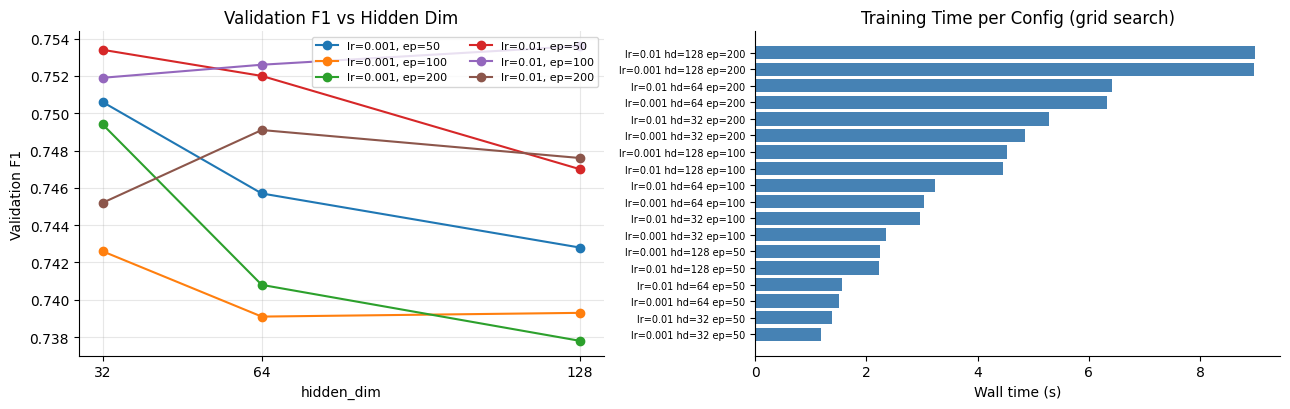

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for lr in LR_VALUES:
    for ep in EPOCH_VALUES:
        sub = (gs_df[(gs_df['lr'] == lr) & (gs_df['epochs'] == ep)]
                 .sort_values('hidden_dim'))
        ax.plot(sub['hidden_dim'], sub['f1'],
                marker='o', label=f'lr={lr}, ep={ep}')
ax.set_xticks(list(HIDDEN_VALUES))
ax.set_xlabel('hidden_dim')
ax.set_ylabel('Validation F1')
ax.set_title('Validation F1 vs Hidden Dim')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc='best', ncol=2)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
gs_sorted = gs_df.sort_values('time_s').reset_index(drop=True)
labels = [f'lr={r.lr} hd={r.hidden_dim} ep={r.epochs}' for r in gs_sorted.itertuples()]
ax.barh(range(len(gs_sorted)), gs_sorted['time_s'], color='steelblue')
ax.set_yticks(range(len(gs_sorted)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Wall time (s)')
ax.set_title('Training Time per Config (grid search)')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

### 5.4 Top 5 configurations (proposal grid)

In [10]:
cols = ['lr','hidden_dim','epochs','f1','accuracy','precision','recall','time_s']
gs_df.sort_values('f1', ascending=False).head(5)[cols].reset_index(drop=True)

,lr,hidden_dim,epochs,f1,accuracy,precision,recall,time_s
0,0.01,128,100,0.7536,0.7479,0.7273,0.7819,4.4665
1,0.01,32,50,0.7534,0.7469,0.7252,0.7839,1.3910
2,0.01,64,100,0.7526,0.7476,0.7283,0.7786,3.2301
3,0.01,64,50,0.7520,0.7484,0.7317,0.7734,1.5604
4,0.01,32,100,0.7519,0.7466,0.7269,0.7788,2.9716


### 5.5 Refined 1-layer search — `lr × hidden × weight_decay × batch_size`

The proposal grid only varies `lr / hidden / epochs`. This refined sweep adds
two regularization-flavored axes that are usually the actual lever for F1:

- `weight_decay`: L2 strength — already a constructor arg on `ANN`
- `batch_size`: smaller batches → noisier gradients ≈ regularization

We fix `epochs=200` with `early_stopping=True, patience=15` so the loop chooses
its own stopping point per config, and we centre `lr / hidden` around the
winner of §4.

Grid: 3 × 2 × 3 × 2 = **36 configurations**.

In [11]:
REFINED_LRS         = (0.005, 0.01, 0.02)
REFINED_HIDDENS     = (128, 256)
REFINED_WDS         = (0.0, 1e-4, 1e-3)
REFINED_BATCH_SIZES = (64, 256)
REFINED_EPOCHS_MAX  = 200
REFINED_PATIENCE    = 15

n_refined = (len(REFINED_LRS) * len(REFINED_HIDDENS)
             * len(REFINED_WDS) * len(REFINED_BATCH_SIZES))
print(f'Refined 1-layer grid: {n_refined} configs '
      f'(epochs≤{REFINED_EPOCHS_MAX} with early stopping)\n')

refined_1l_results = []
t_grid = time.time()
for lr in REFINED_LRS:
    for hd in REFINED_HIDDENS:
        for wd in REFINED_WDS:
            for bs in REFINED_BATCH_SIZES:
                t0 = time.time()
                m = ANN(
                    input_dim=X_tr.shape[1],
                    hidden_dim=hd,
                    learning_rate=lr,
                    epochs=REFINED_EPOCHS_MAX,
                    batch_size=bs,
                    weight_decay=wd,
                    early_stopping=True,
                    patience=REFINED_PATIENCE,
                )
                m.fit(X_tr, y_tr, X_val, y_val)
                y_p   = m.predict(X_val)
                met   = compute_metrics(y_val, y_p)
                eu    = len(m.train_loss_history)
                dt    = time.time() - t0
                print(f'  lr={lr:<6} hd={hd:<4} wd={wd:<6} bs={bs:<4} → '
                      f'F1={met["f1"]:.4f}  Acc={met["accuracy"]:.4f}  '
                      f'(stopped@{eu}, {dt:.1f}s)')
                refined_1l_results.append({
                    'arch': '1L', 'lr': lr, 'hidden': str(hd),
                    'wd': wd, 'batch_size': bs,
                    'epochs_used': eu, **met, 'time_s': dt,
                })
print(f'\nRefined 1L grid took {time.time()-t_grid:.1f}s')

Refined 1-layer grid: 36 configs (epochs≤200 with early stopping)

  lr=0.005  hd=128  wd=0.0    bs=64   → F1=0.7545  Acc=0.7428  (stopped@18, 1.6s)
  lr=0.005  hd=128  wd=0.0    bs=256  → F1=0.7563  Acc=0.7437  (stopped@36, 1.7s)
  lr=0.005  hd=128  wd=0.0001 bs=64   → F1=0.7553  Acc=0.7481  (stopped@22, 2.0s)
  lr=0.005  hd=128  wd=0.0001 bs=256  → F1=0.7544  Acc=0.7448  (stopped@41, 2.0s)
  lr=0.005  hd=128  wd=0.001  bs=64   → F1=0.7523  Acc=0.7478  (stopped@28, 2.7s)
  lr=0.005  hd=128  wd=0.001  bs=256  → F1=0.7553  Acc=0.7479  (stopped@41, 2.0s)
  lr=0.005  hd=256  wd=0.0    bs=64   → F1=0.7544  Acc=0.7459  (stopped@19, 2.6s)
  lr=0.005  hd=256  wd=0.0    bs=256  → F1=0.7427  Acc=0.7417  (stopped@23, 1.9s)
  lr=0.005  hd=256  wd=0.0001 bs=64   → F1=0.7521  Acc=0.7483  (stopped@36, 5.0s)
  lr=0.005  hd=256  wd=0.0001 bs=256  → F1=0.7539  Acc=0.7480  (stopped@34, 2.9s)
  lr=0.005  hd=256  wd=0.001  bs=64   → F1=0.7568  Acc=0.7480  (stopped@41, 5.5s)
  lr=0.005  hd=256  wd=0.001  b

In [12]:
ref1_df = pd.DataFrame(refined_1l_results).round(4)
print('Top 5 refined 1-layer configs:')
ref1_df.sort_values('f1', ascending=False).head(5)[
    ['lr','hidden','wd','batch_size','epochs_used','f1','accuracy','precision','recall','time_s']
].reset_index(drop=True)

Top 5 refined 1-layer configs:


,lr,hidden,wd,batch_size,epochs_used,f1,accuracy,precision,recall,time_s
0,0.01,128,0.0010,256,63,0.7583,0.7482,0.7200,0.8010,3.0158
1,0.02,256,0.0010,64,31,0.7580,0.7449,0.7122,0.8102,4.0913
2,0.02,128,0.0001,256,41,0.7570,0.7477,0.7208,0.7971,1.9775
3,0.02,128,0.0010,256,36,0.7570,0.7460,0.7167,0.8021,1.7201
4,0.01,128,0.0000,256,32,0.7569,0.7450,0.7144,0.8047,1.4993


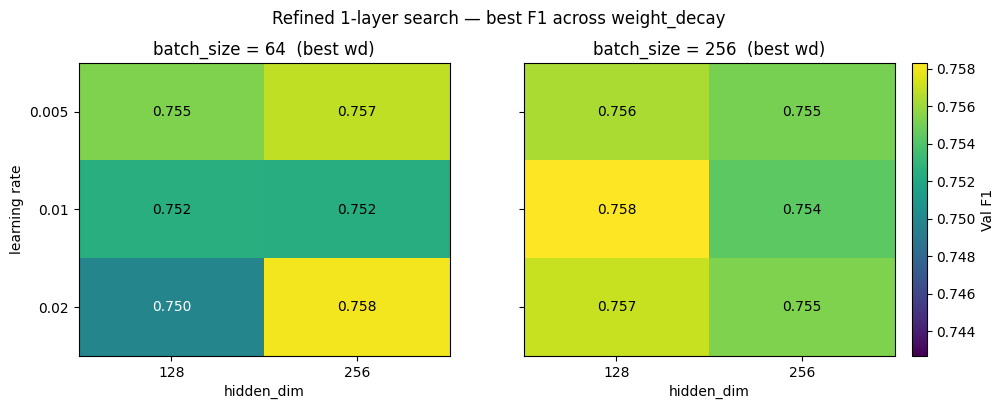

In [13]:
# Heatmap: F1 vs (lr × hidden) marginalised over (wd, batch_size) by max
fig, axes = plt.subplots(1, len(REFINED_BATCH_SIZES), figsize=(5.6*len(REFINED_BATCH_SIZES), 3.8),
                         sharey=True)
if len(REFINED_BATCH_SIZES) == 1:
    axes = [axes]

vmin = ref1_df['f1'].min(); vmax = ref1_df['f1'].max()

for ax, bs in zip(axes, REFINED_BATCH_SIZES):
    sub = ref1_df[ref1_df['batch_size'] == bs]
    # group by (lr, hidden) → take best F1 across wd
    best = (sub.groupby(['lr','hidden'])['f1'].max().reset_index())
    pivot = best.pivot(index='lr', columns='hidden', values='f1')
    pivot = pivot[[str(h) for h in REFINED_HIDDENS]]
    im = ax.imshow(pivot.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel('hidden_dim')
    if ax is axes[0]: ax.set_ylabel('learning rate')
    ax.set_title(f'batch_size = {bs}  (best wd)')
    mid = (vmin+vmax)/2
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v < mid else 'black', fontsize=10)

fig.colorbar(im, ax=axes, label='Val F1', fraction=0.04, pad=0.02)
plt.suptitle('Refined 1-layer search — best F1 across weight_decay', y=1.02, fontsize=12)
plt.show()

### 5.6 Two-layer search — `ANN2`

Adds depth via `ANN2` (`ANNNet2` from `ann_model.py`). Three reasonable
shape options, two `lr`s, two `weight_decay`s, fixed `batch_size=128`,
`epochs=200` w/ early stopping.

Grid: 3 × 2 × 2 = **12 configurations**.

In [14]:
TWO_LAYER_DIMS = ((128, 64), (256, 128), (256, 64))
TWO_LAYER_LRS  = (0.005, 0.01)
TWO_LAYER_WDS  = (0.0, 1e-4)
TWO_LAYER_BS   = 128
TWO_LAYER_EP   = 200
TWO_LAYER_PAT  = 15

n_2l = len(TWO_LAYER_DIMS) * len(TWO_LAYER_LRS) * len(TWO_LAYER_WDS)
print(f'2-layer grid: {n_2l} configs (epochs≤{TWO_LAYER_EP} with early stopping)\n')

two_layer_results = []
t_grid = time.time()
for hd in TWO_LAYER_DIMS:
    for lr in TWO_LAYER_LRS:
        for wd in TWO_LAYER_WDS:
            t0 = time.time()
            m = ANN2(
                input_dim=X_tr.shape[1],
                hidden_dims=hd,
                learning_rate=lr,
                epochs=TWO_LAYER_EP,
                batch_size=TWO_LAYER_BS,
                weight_decay=wd,
                early_stopping=True,
                patience=TWO_LAYER_PAT,
            )
            m.fit(X_tr, y_tr, X_val, y_val)
            y_p = m.predict(X_val)
            met = compute_metrics(y_val, y_p)
            eu  = len(m.train_loss_history)
            dt  = time.time() - t0
            print(f'  hd={str(hd):<12} lr={lr:<6} wd={wd:<6} → '
                  f'F1={met["f1"]:.4f}  Acc={met["accuracy"]:.4f}  '
                  f'(stopped@{eu}, {dt:.1f}s)')
            two_layer_results.append({
                'arch': '2L', 'lr': lr, 'hidden': str(hd),
                'wd': wd, 'batch_size': TWO_LAYER_BS,
                'epochs_used': eu, **met, 'time_s': dt,
            })
print(f'\n2L grid took {time.time()-t_grid:.1f}s')

2-layer grid: 12 configs (epochs≤200 with early stopping)

  hd=(128, 64)    lr=0.005  wd=0.0    → F1=0.7473  Acc=0.7426  (stopped@23, 2.7s)
  hd=(128, 64)    lr=0.005  wd=0.0001 → F1=0.7587  Acc=0.7487  (stopped@44, 4.6s)
  hd=(128, 64)    lr=0.01   wd=0.0    → F1=0.7590  Acc=0.7453  (stopped@23, 3.1s)
  hd=(128, 64)    lr=0.01   wd=0.0001 → F1=0.7578  Acc=0.7486  (stopped@39, 4.1s)
  hd=(256, 128)   lr=0.005  wd=0.0    → F1=0.7517  Acc=0.7427  (stopped@23, 6.0s)
  hd=(256, 128)   lr=0.005  wd=0.0001 → F1=0.7571  Acc=0.7463  (stopped@34, 7.4s)
  hd=(256, 128)   lr=0.01   wd=0.0    → F1=0.7487  Acc=0.7430  (stopped@18, 4.3s)
  hd=(256, 128)   lr=0.01   wd=0.0001 → F1=0.7533  Acc=0.7473  (stopped@28, 6.2s)
  hd=(256, 64)    lr=0.005  wd=0.0    → F1=0.7510  Acc=0.7437  (stopped@19, 3.2s)
  hd=(256, 64)    lr=0.005  wd=0.0001 → F1=0.7557  Acc=0.7452  (stopped@42, 6.8s)
  hd=(256, 64)    lr=0.01   wd=0.0    → F1=0.7539  Acc=0.7463  (stopped@28, 4.9s)
  hd=(256, 64)    lr=0.01   wd=0.0001 →

In [15]:
ref2_df = pd.DataFrame(two_layer_results).round(4)
print('Top 5 2-layer configs:')
ref2_df.sort_values('f1', ascending=False).head(5)[
    ['hidden','lr','wd','batch_size','epochs_used','f1','accuracy','precision','recall','time_s']
].reset_index(drop=True)

Top 5 2-layer configs:


,hidden,lr,wd,batch_size,epochs_used,f1,accuracy,precision,recall,time_s
0,"(128, 64)",0.010,0.0000,128,23,0.7590,0.7453,0.7115,0.8134,3.0825
1,"(128, 64)",0.005,0.0001,128,44,0.7587,0.7487,0.7204,0.8013,4.6146
2,"(256, 64)",0.010,0.0001,128,45,0.7585,0.7458,0.7134,0.8097,7.3337
3,"(128, 64)",0.010,0.0001,128,39,0.7578,0.7486,0.7219,0.7974,4.1295
4,"(256, 128)",0.005,0.0001,128,34,0.7571,0.7463,0.7173,0.8015,7.3826


### 5.7 Cross-architecture leaderboard

Stack §5.5 (1-layer refined) and §5.6 (2-layer) into one ranked table. The
winner here is what feeds into §6 (final training).

In [16]:
leaderboard = pd.concat([ref1_df, ref2_df], ignore_index=True)
leaderboard_sorted = leaderboard.sort_values('f1', ascending=False).reset_index(drop=True)
leaderboard_sorted.head(10)[
    ['arch','hidden','lr','wd','batch_size','epochs_used','f1','accuracy','precision','recall']
]

,arch,hidden,lr,wd,batch_size,epochs_used,f1,accuracy,precision,recall
0,2L,"(128, 64)",0.010,0.0000,128,23,0.7590,0.7453,0.7115,0.8134
1,2L,"(128, 64)",0.005,0.0001,128,44,0.7587,0.7487,0.7204,0.8013
2,2L,"(256, 64)",0.010,0.0001,128,45,0.7585,0.7458,0.7134,0.8097
3,1L,128,0.010,0.0010,256,63,0.7583,0.7482,0.7200,0.8010
4,1L,256,0.020,0.0010,64,31,0.7580,0.7449,0.7122,0.8102
5,2L,"(128, 64)",0.010,0.0001,128,39,0.7578,0.7486,0.7219,0.7974
6,2L,"(256, 128)",0.005,0.0001,128,34,0.7571,0.7463,0.7173,0.8015
7,1L,128,0.020,0.0010,256,36,0.7570,0.7460,0.7167,0.8021
8,1L,128,0.020,0.0001,256,41,0.7570,0.7477,0.7208,0.7971
9,1L,128,0.010,0.0000,256,32,0.7569,0.7450,0.7144,0.8047


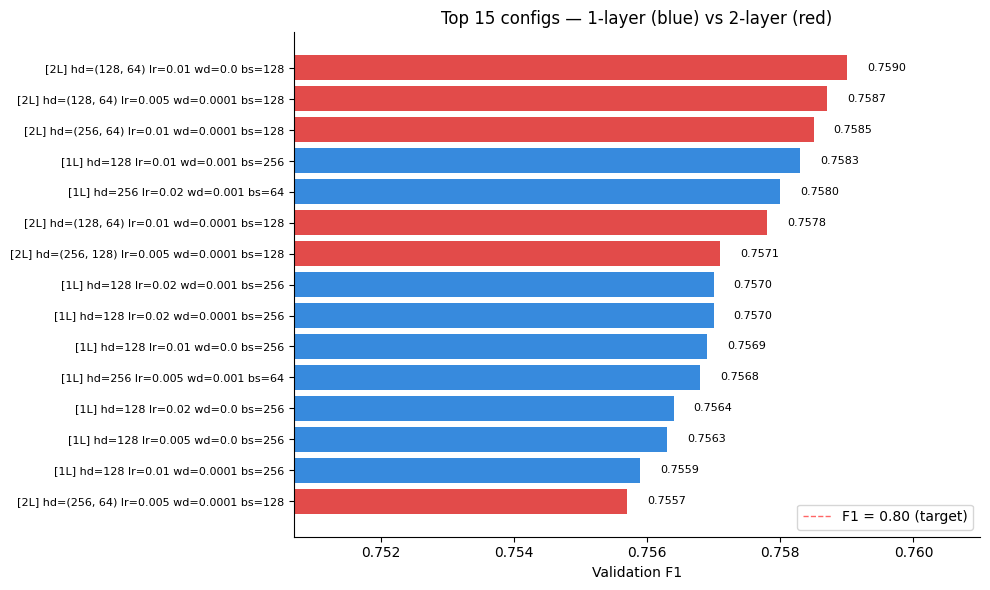

In [17]:
# Bar chart: top-15 configs across both architectures
top15 = leaderboard_sorted.head(15).copy()
labels = [f"[{r.arch}] hd={r.hidden} lr={r.lr} wd={r.wd} bs={r.batch_size}"
          for r in top15.itertuples()]
colors = ['#378ADD' if a == '1L' else '#E24B4A' for a in top15['arch']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top15))[::-1], top15['f1'], color=colors)
ax.set_yticks(range(len(top15))[::-1])
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Validation F1')
ax.set_xlim(top15['f1'].min() - 0.005, top15['f1'].max() + 0.002)
ax.axvline(0.80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='F1 = 0.80 (target)')
ax.set_title('Top 15 configs — 1-layer (blue) vs 2-layer (red)')
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='lower right')
for bar, val in zip(bars, top15['f1']):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
global_best = leaderboard_sorted.iloc[0].to_dict()
print('★ Global best config:')
for k in ['arch','hidden','lr','wd','batch_size','epochs_used','f1','accuracy','precision','recall']:
    print(f'  {k:14s}: {global_best[k]}')

★ Global best config:
  arch          : 2L
  hidden        : (128, 64)
  lr            : 0.01
  wd            : 0.0
  batch_size    : 128
  epochs_used   : 23
  f1            : 0.759
  accuracy      : 0.7453
  precision     : 0.7115
  recall        : 0.8134


### 5.8 Decision-threshold tuning on the global winner

F1 is maximised at the threshold where `precision == recall` (roughly), which
is rarely exactly `0.5`. Re-fit the global winner once, then sweep the
decision threshold over the validation `predict_proba` output.

This is essentially free (single training run, vectorised threshold sweep) and
is usually the highest-leverage F1 trick when the goal is `F1 > 0.x`.

In [19]:
# Build the winner
if global_best['arch'] == '2L':
    hd_tuple = eval(global_best['hidden'])  # str like '(128, 64)' → tuple
    winner = ANN2(
        input_dim=X_tr.shape[1],
        hidden_dims=hd_tuple,
        learning_rate=global_best['lr'],
        epochs=300,
        batch_size=int(global_best['batch_size']),
        weight_decay=global_best['wd'],
        early_stopping=True, patience=20,
    )
else:
    winner = ANN(
        input_dim=X_tr.shape[1],
        hidden_dim=int(global_best['hidden']),
        learning_rate=global_best['lr'],
        epochs=300,
        batch_size=int(global_best['batch_size']),
        weight_decay=global_best['wd'],
        early_stopping=True, patience=20,
    )

winner.fit(X_tr, y_tr, X_val, y_val)
val_proba = winner.predict_proba(X_val)

thresholds = np.linspace(0.05, 0.95, 91)
f1_curve = []
for t in thresholds:
    y_pred_t = (val_proba >= t).astype(np.float64)
    f1_curve.append(compute_metrics(y_val, y_pred_t)['f1'])
f1_curve = np.array(f1_curve)

best_t   = thresholds[int(np.argmax(f1_curve))]
best_f1  = f1_curve.max()
default  = compute_metrics(y_val, (val_proba >= 0.5).astype(np.float64))['f1']

print(f'Default threshold (0.50)       → val F1 = {default:.4f}')
print(f'Best threshold ({best_t:.2f})           → val F1 = {best_f1:.4f}')
print(f'Δ F1 from threshold tuning      = {best_f1 - default:+.4f}')

Default threshold (0.50)       → val F1 = 0.7590
Best threshold (0.39)           → val F1 = 0.7692
Δ F1 from threshold tuning      = +0.0102


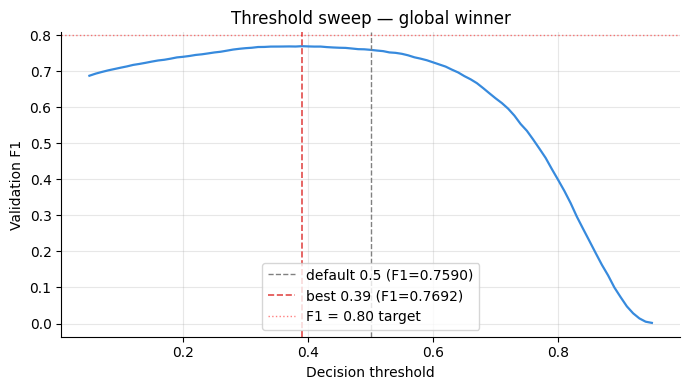

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_curve, color='#378ADD', linewidth=1.6)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label=f'default 0.5 (F1={default:.4f})')
ax.axvline(best_t, color='#E24B4A', linestyle='--', linewidth=1.2,
           label=f'best {best_t:.2f} (F1={best_f1:.4f})')
ax.axhline(0.80, color='red', linestyle=':', linewidth=1, alpha=0.5, label='F1 = 0.80 target')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Validation F1')
ax.set_title('Threshold sweep — global winner')
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
ax.legend(loc='lower center')
plt.tight_layout()
plt.show()

## 6. Final Model

Defaults to the §5.7 leaderboard winner + §5.8 tuned threshold. Override any
of `BEST_ARCH / BEST_HIDDEN / BEST_LR / BEST_WD / BEST_BATCH / BEST_EPOCHS / BEST_THRESHOLD`
if you want to lock in a specific run from the Colab grid output.

In [21]:
# === Final hyperparameters (override after reviewing §5.7 / §5.8) ===
BEST_ARCH      = global_best['arch']           # '1L' or '2L'
BEST_HIDDEN    = global_best['hidden']         # int (1L) or '(h1, h2)' str (2L)
BEST_LR        = global_best['lr']
BEST_WD        = global_best['wd']
BEST_BATCH     = int(global_best['batch_size'])
BEST_EPOCHS    = 300                           # early stopping decides actual
BEST_PATIENCE  = 20
BEST_THRESHOLD = float(best_t)                 # from §5.8

print(f'Final config:')
print(f'  arch      = {BEST_ARCH}')
print(f'  hidden    = {BEST_HIDDEN}')
print(f'  lr        = {BEST_LR}')
print(f'  wd        = {BEST_WD}')
print(f'  batch     = {BEST_BATCH}')
print(f'  epochs    = {BEST_EPOCHS}  (patience={BEST_PATIENCE})')
print(f'  threshold = {BEST_THRESHOLD:.3f}')

Final config:
  arch      = 2L
  hidden    = (128, 64)
  lr        = 0.01
  wd        = 0.0
  batch     = 128
  epochs    = 300  (patience=20)
  threshold = 0.390


### 6.1 Train final model with early stopping

In [22]:
if BEST_ARCH == '2L':
    hd_tuple = eval(BEST_HIDDEN) if isinstance(BEST_HIDDEN, str) else tuple(BEST_HIDDEN)
    final_model = ANN2(
        input_dim=X_train.shape[1],
        hidden_dims=hd_tuple,
        learning_rate=BEST_LR,
        epochs=BEST_EPOCHS,
        batch_size=BEST_BATCH,
        weight_decay=BEST_WD,
        early_stopping=True, patience=BEST_PATIENCE,
        verbose=True,
    )
else:
    hd_int = int(BEST_HIDDEN)
    final_model = ANN(
        input_dim=X_train.shape[1],
        hidden_dim=hd_int,
        learning_rate=BEST_LR,
        epochs=BEST_EPOCHS,
        batch_size=BEST_BATCH,
        weight_decay=BEST_WD,
        early_stopping=True, patience=BEST_PATIENCE,
        verbose=True,
    )

t0 = time.time()
final_model.fit(X_tr, y_tr, X_val, y_val)
print(f'\nTraining time: {time.time()-t0:.1f}s')
print(f'Stopped after {len(final_model.train_loss_history)} epochs')

    [early stop] epoch 28, best val_loss=0.5088

Training time: 3.3s
Stopped after 28 epochs


### 6.2 Training curves

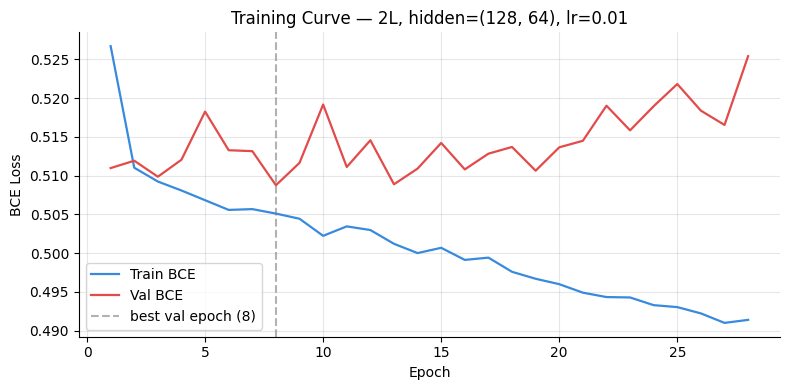

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_axis = range(1, len(final_model.train_loss_history) + 1)
ax.plot(epochs_axis, final_model.train_loss_history,
        label='Train BCE', linewidth=1.6, color='#378ADD')
if final_model.val_loss_history:
    ax.plot(range(1, len(final_model.val_loss_history) + 1),
            final_model.val_loss_history,
            label='Val BCE', linewidth=1.6, color='#E24B4A')
    best_ep = int(np.argmin(final_model.val_loss_history)) + 1
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6,
               label=f'best val epoch ({best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title(f'Training Curve — {BEST_ARCH}, hidden={BEST_HIDDEN}, lr={BEST_LR}')
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Test Set Evaluation

Reports both default-threshold (0.5) and tuned-threshold metrics.

In [24]:
t0      = time.time()
y_proba = final_model.predict_proba(X_test)
print(f'Inference time: {time.time()-t0:.2f}s')

y_pred_default = (y_proba >= 0.5).astype(np.float64)
y_pred_tuned   = (y_proba >= BEST_THRESHOLD).astype(np.float64)

test_default = compute_metrics(y_test, y_pred_default, y_proba)
test_tuned   = compute_metrics(y_test, y_pred_tuned,   y_proba)

results_df = pd.DataFrame([
    {
        'Variant': 'threshold = 0.50 (default)',
        'Accuracy':  round(test_default['accuracy'],  4),
        'Precision': round(test_default['precision'], 4),
        'Recall':    round(test_default['recall'],    4),
        'F1-Score':  round(test_default['f1'],        4),
        'AUC-ROC':   round(test_default['auc_roc'],   4),
    },
    {
        'Variant': f'threshold = {BEST_THRESHOLD:.2f} (tuned)',
        'Accuracy':  round(test_tuned['accuracy'],  4),
        'Precision': round(test_tuned['precision'], 4),
        'Recall':    round(test_tuned['recall'],    4),
        'F1-Score':  round(test_tuned['f1'],        4),
        'AUC-ROC':   round(test_tuned['auc_roc'],   4),
    },
])

# Use the tuned variant as the headline result
y_pred = y_pred_tuned
test_m = test_tuned
results_df

Inference time: 0.01s


,Variant,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,threshold = 0.50 (default),0.7515,0.7179,0.8140,0.7629,0.827
1,threshold = 0.39 (tuned),0.7417,0.6841,0.8808,0.7701,0.827


### 7.1 Confusion matrix (tuned threshold)

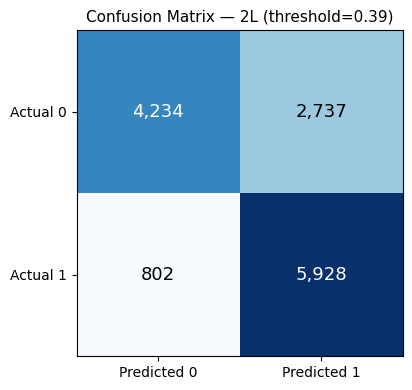

In [25]:
cm = np.array([[test_m['TN'], test_m['FP']],
               [test_m['FN'], test_m['TP']]])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=13,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])
ax.set_title(f'Confusion Matrix — {BEST_ARCH} (threshold={BEST_THRESHOLD:.2f})',
             fontsize=11)
plt.tight_layout()
plt.show()

### 7.2 ROC curve

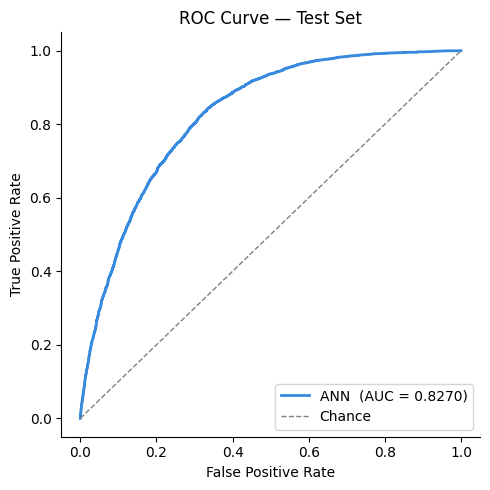

In [26]:
thresholds_roc = np.sort(np.unique(y_proba))[::-1]
pos = y_test.sum()
neg = len(y_test) - pos
tprs, fprs = [0.0], [0.0]
for t in thresholds_roc:
    pred = (y_proba >= t).astype(float)
    tprs.append(np.sum((pred == 1) & (y_test == 1)) / pos)
    fprs.append(np.sum((pred == 1) & (y_test == 0)) / neg)
tprs.append(1.0); fprs.append(1.0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fprs, tprs, color='#378ADD', linewidth=2,
        label=f'ANN  (AUC = {test_m["auc_roc"]:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Permutation Feature Importance

Same `permutation_importance` helper used by KNN / LogReg, so the resulting
ΔF1 scores are directly comparable across models. (Uses default threshold 0.5
internally via `model.predict`.)

In [27]:
print('Computing permutation feature importance (n_repeats=3) ...')
importances = permutation_importance(
    final_model, X_test, y_test, feature_names,
    n_repeats=3, metric='f1',
)

Computing permutation feature importance (n_repeats=3) ...
  [01/21] HighBP                       Δf1=+0.0141
  [02/21] HighChol                     Δf1=+0.0111
  [03/21] CholCheck                    Δf1=+0.0054
  [04/21] Smoker                       Δf1=-0.0008
  [05/21] Stroke                       Δf1=+0.0008
  [06/21] HeartDiseaseorAttack         Δf1=+0.0018
  [07/21] PhysActivity                 Δf1=+0.0002
  [08/21] Fruits                       Δf1=+0.0015
  [09/21] Veggies                      Δf1=-0.0014
  [10/21] HvyAlcoholConsump            Δf1=+0.0029
  [11/21] AnyHealthcare                Δf1=+0.0005
  [12/21] NoDocbcCost                  Δf1=-0.0001
  [13/21] DiffWalk                     Δf1=-0.0004
  [14/21] Sex                          Δf1=+0.0035
  [15/21] GenHlth                      Δf1=+0.0435
  [16/21] Age                          Δf1=+0.0270
  [17/21] Education                    Δf1=-0.0001
  [18/21] Income                       Δf1=+0.0010
  [19/21] BMI          

In [28]:
ranked = np.argsort(importances)[::-1]
fi_df = pd.DataFrame({
    'Rank':    range(1, len(feature_names) + 1),
    'Feature': [feature_names[i] for i in ranked],
    'Δ F1':    [round(importances[i], 4) for i in ranked],
})
fi_df

,Rank,Feature,Δ F1
0,1,GenHlth,0.0435
1,2,BMI,0.0301
2,3,Age,0.0270
3,4,HighBP,0.0141
4,5,HighChol,0.0111
5,6,CholCheck,0.0054
6,7,Sex,0.0035
7,8,HvyAlcoholConsump,0.0029
8,9,HeartDiseaseorAttack,0.0018
9,10,Fruits,0.0015


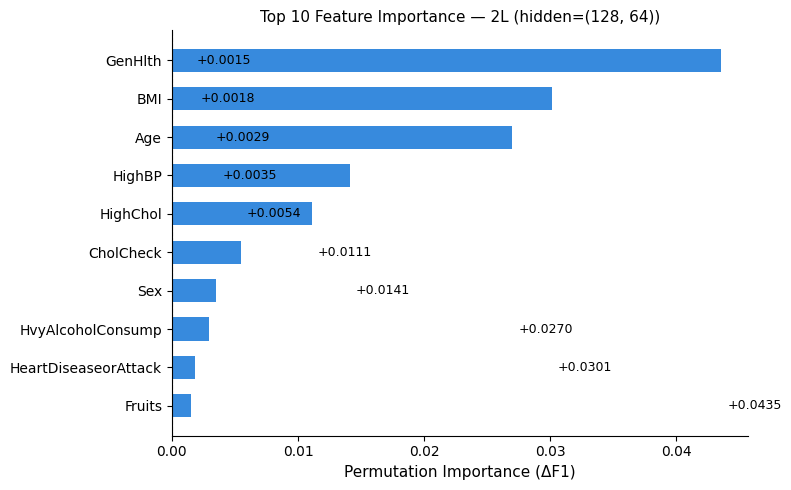

In [29]:
top_n   = 10
top_idx = ranked[:top_n]
top_features = [feature_names[i] for i in top_idx]
top_scores   = [importances[i] for i in top_idx]
colors = ['#378ADD' if s >= 0 else '#E24B4A' for s in top_scores]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top_features[::-1], top_scores[::-1],
               color=colors[::-1], height=0.6)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Permutation Importance (ΔF1)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importance — {BEST_ARCH} '
             f'(hidden={BEST_HIDDEN})',
             fontsize=11)
ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars[::-1], top_scores[::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Save Artifacts

Mirrors the naming convention used by `knn_model.py` / `logistic_regression.py`.
For 2-layer models we save weights as `W1/b1/W2/b2/W3/b3` instead of
`W1/b1/W2/b2`.

In [30]:
os.makedirs('models', exist_ok=True)

np.save('models/ann_y_pred.npy',      y_pred)
np.save('models/ann_y_proba.npy',     y_proba)
np.save('models/ann_importances.npy', importances)

if BEST_ARCH == '2L':
    np.savez('models/ann_weights.npz',
             W1=final_model.net.params['W1'], b1=final_model.net.params['b1'],
             W2=final_model.net.params['W2'], b2=final_model.net.params['b2'],
             W3=final_model.net.params['W3'], b3=final_model.net.params['b3'])
else:
    np.savez('models/ann_weights.npz',
             W1=final_model.net.params['W1'], b1=final_model.net.params['b1'],
             W2=final_model.net.params['W2'], b2=final_model.net.params['b2'])

np.save('models/ann_best_config.npy',
        np.array([BEST_ARCH, BEST_HIDDEN, BEST_LR, BEST_WD,
                  BEST_BATCH, BEST_EPOCHS, BEST_THRESHOLD], dtype=object))
np.save('models/ann_train_loss.npy', np.array(final_model.train_loss_history))
np.save('models/ann_val_loss.npy',   np.array(final_model.val_loss_history))

with open('models/ann_grid_search.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=gs_results[0].keys())
    writer.writeheader()
    writer.writerows(gs_results)

leaderboard.to_csv('models/ann_leaderboard.csv', index=False)

print('Saved:')
for name in ['ann_y_pred.npy', 'ann_y_proba.npy', 'ann_importances.npy',
             'ann_weights.npz', 'ann_best_config.npy',
             'ann_train_loss.npy', 'ann_val_loss.npy',
             'ann_grid_search.csv', 'ann_leaderboard.csv']:
    print(f'  models/{name}')

Saved:
  models/ann_y_pred.npy
  models/ann_y_proba.npy
  models/ann_importances.npy
  models/ann_weights.npz
  models/ann_best_config.npy
  models/ann_train_loss.npy
  models/ann_val_loss.npy
  models/ann_grid_search.csv
  models/ann_leaderboard.csv


## 10. Summary

| Stage | Configs | Notes |
|---|---|---|
| §4 Proposal grid | 18 | `lr × hidden × epochs`, fixed batch/wd, no early stop |
| §5.5 Refined 1L  | 36 | Adds `weight_decay × batch_size`, early stopping |
| §5.6 2-layer      | 12 | `ANN2` (`ANNNet2`) — extension beyond proposal |
| §5.7 Leaderboard  | 66 | Stacked + sorted by val F1 |
| §5.8 Threshold    | 91 | Sweep over single best model — usually +0.01–0.03 F1 |
| §6 Final          | 1  | Best arch retrained, evaluated at tuned threshold |

**Realistic ceiling:** Public benchmarks on this BRFSS 2015 50/50 split land
around **F1 = 0.74–0.78** for traditional ML. Reaching **F1 > 0.80** without
ensembling, feature engineering, or richer features (lab values like HbA1c)
is unlikely — but threshold tuning + 2-layer architecture is the strongest
lever inside this notebook's scope.